Descargando BTC...


[*********************100%***********************]  1 of 1 completed


Descargando MSTR...


[*********************100%***********************]  1 of 1 completed



--- ÉXITO ---
Filas alineadas y limpias: 3443
                                    BTC       MSTR
Datetime                                          
2024-02-20 14:00:00+00:00  52013.222656  68.650002
2024-02-20 15:00:00+00:00  51707.675781  69.806000
2024-02-20 16:00:00+00:00  51370.734375  67.699997
2024-02-20 17:00:00+00:00  51312.492188  68.503120
2024-02-20 18:00:00+00:00  51500.457031  69.597000


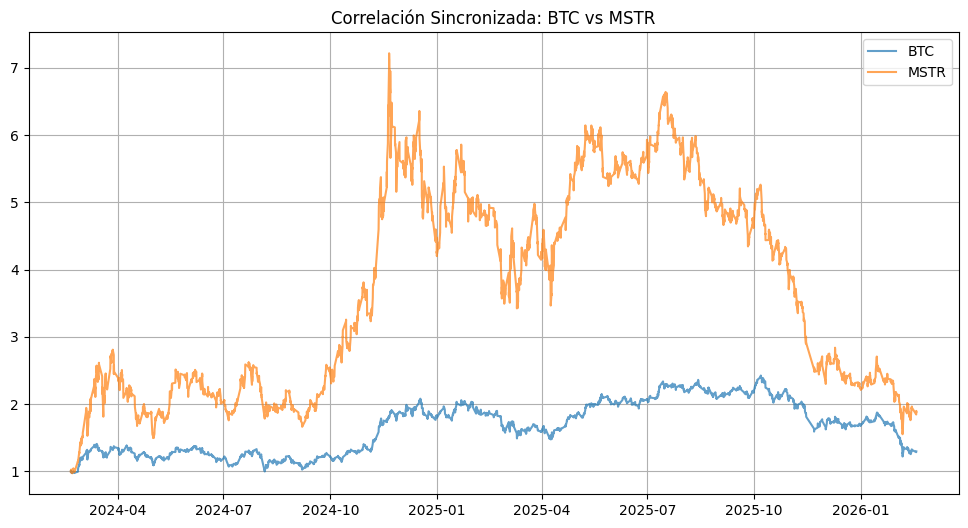

Guardado en 'datos_mstr_btc_1h.csv'


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. DESCARGA POR SEPARADO (Divide y vencerás)
print("Descargando BTC...")
# auto_adjust=True nos da el precio limpio directamente
btc = yf.download('BTC-USD', period='730d', interval='1h', auto_adjust=True)

print("Descargando MSTR...")
mstr = yf.download('MSTR', period='730d', interval='1h', auto_adjust=True)

# 2. LIMPIEZA DE COLUMNAS (Manejo del MultiIndex rebelde)
# A veces yfinance devuelve (Price, Ticker) y a veces solo (Price).
# Esta función asegura que nos quedamos solo con la columna 'Close' como una Serie limpia.
def limpiar_datos(df, ticker_name):
    # Si tiene columnas con niveles (Price, Ticker), extraemos 'Close'
    if isinstance(df.columns, pd.MultiIndex):
        try:
            # Intenta sacar la columna Close de ese ticker especifico
            return df.xs('Close', axis=1, level=0)[ticker_name]
        except:
            # Si falla, intenta sacar solo 'Close' si el nivel ticker no está claro
            return df['Close']
    else:
        # Si es un dataframe plano
        return df['Close']

# Aplicamos la limpieza
btc_clean = limpiar_datos(btc, 'BTC-USD')
mstr_clean = limpiar_datos(mstr, 'MSTR')

# 3. SINCRONIZACIÓN TEMPORAL (Aquí está la magia física)
# Convertimos todo a UTC para evitar líos de zonas horarias
btc_clean.index = btc_clean.index.tz_convert('UTC')
mstr_clean.index = mstr_clean.index.tz_convert('UTC')

# TRUCO: "Aplanar" los minutos. 
# Si MSTR es 13:30, lo convertimos a 13:00 para que coincida con BTC.
# .floor('H') redondea a la hora inferior.
mstr_clean.index = mstr_clean.index.floor('h')
btc_clean.index = btc_clean.index.floor('h')

# 4. FUSIÓN (MERGE)
# Ahora que los índices son idénticos (horas en punto), unimos.
df_final = pd.concat([btc_clean, mstr_clean], axis=1)
df_final.columns = ['BTC', 'MSTR']

# 5. LIMPIEZA FINAL
# Borramos filas donde falte uno de los dos (fines de semana, noches)
df_final = df_final.dropna()

print(f"\n--- ÉXITO ---")
print(f"Filas alineadas y limpias: {len(df_final)}")
print(df_final.head())

# 6. VISUALIZACIÓN
# Normalizamos para ver la comparativa
df_norm = df_final / df_final.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(df_norm.index, df_norm['BTC'], label='BTC', alpha=0.7)
plt.plot(df_norm.index, df_norm['MSTR'], label='MSTR', alpha=0.7)
plt.title('Correlación Sincronizada: BTC vs MSTR')
plt.legend()
plt.grid(True)
plt.show()

# 7. GUARDAR
df_final.to_csv('datos_mstr_btc_1h.csv')
print("Guardado en 'datos_mstr_btc_1h.csv'")

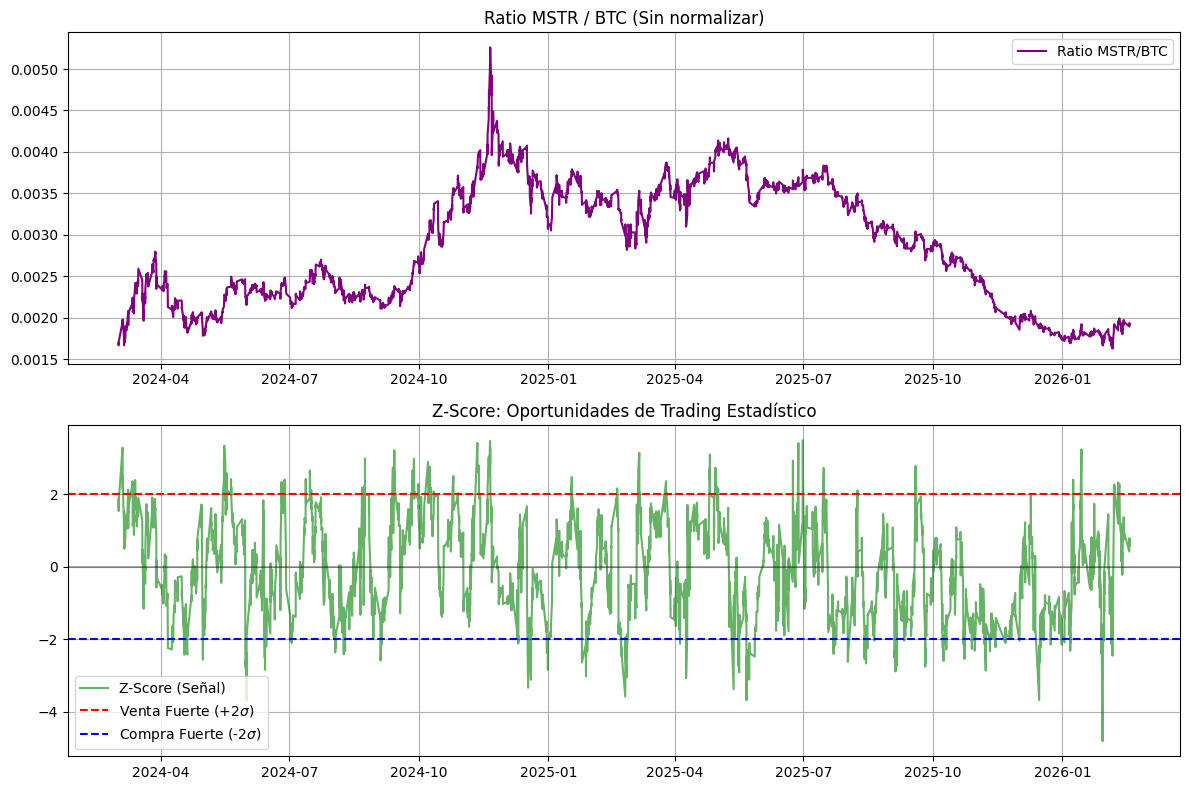

Dataset con features generado: 'datos_entrenamiento.csv'


In [2]:
# 1. CARGAR DATOS
df = pd.read_csv('datos_mstr_btc_1h.csv', index_col=0, parse_dates=True)

# 2. FEATURE ENGINEERING (Ingeniería de Variables)

# A) Retornos Logarítmicos (Velocidad del precio)
# Es mejor que el porcentaje simple porque es sumable en el tiempo y simétrico.
df['lret_btc'] = np.log(df['BTC'] / df['BTC'].shift(1))
df['lret_mstr'] = np.log(df['MSTR'] / df['MSTR'].shift(1))

# B) El Ratio Simple (Posición relativa)
df['ratio'] = df['MSTR'] / df['BTC']

# C) Indicadores Técnicos de la Relación (Dinámica del sistema)
# Usamos una ventana móvil (Rolling Window) para que el modelo se adapte al pasado reciente.
# Ventana de 1 semana (aprox 40 horas de trading activo o 168h naturales, probemos con 60 periodos de datos)
WINDOW = 60 

# Media móvil y Desviación estándar del ratio
df['ratio_mean'] = df['ratio'].rolling(window=WINDOW).mean()
df['ratio_std'] = df['ratio'].rolling(window=WINDOW).std()

# D) Z-SCORE (La señal normalizada)
# Fórmula: (Valor actual - Media) / Desviación Estándar
# Esto nos dice: "¿Qué tan rara es la separación actual entre BTC y MSTR?"
df['z_score'] = (df['ratio'] - df['ratio_mean']) / df['ratio_std']

# Limpiamos los NaN que generan las ventanas móviles al principio
df = df.dropna()

# 3. VISUALIZACIÓN DE LA SEÑAL
# Esto es lo que verá tu bot. Ya no ve precios que suben al infinito.
# Ve una señal que oscila alrededor de cero.
plt.figure(figsize=(12, 8))

# Subplot 1: El Ratio
plt.subplot(2, 1, 1)
plt.plot(df.index, df['ratio'], label='Ratio MSTR/BTC', color='purple')
plt.title('Ratio MSTR / BTC (Sin normalizar)')
plt.legend()
plt.grid(True)

# Subplot 2: El Z-Score (Lo que usa el bot)
plt.subplot(2, 1, 2)
plt.plot(df.index, df['z_score'], label='Z-Score (Señal)', color='green', alpha=0.6)
# Dibujamos bandas de "exceso" (2 Sigma)
plt.axhline(2, color='red', linestyle='--', label='Venta Fuerte (+2$\sigma$)')
plt.axhline(-2, color='blue', linestyle='--', label='Compra Fuerte (-2$\sigma$)')
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.title('Z-Score: Oportunidades de Trading Estadístico')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Guardamos el dataset enriquecido
df.to_csv('datos_entrenamiento.csv')
print("Dataset con features generado: 'datos_entrenamiento.csv'")

In [3]:
# 1. CARGAR
df = pd.read_csv('datos_entrenamiento.csv', index_col=0, parse_dates=True)

# 2. CREAR EL TARGET (El objetivo a predecir)
# Queremos saber si el Ratio subirá o bajará en el futuro.
# HORIZONTE DE PREDICCIÓN: 5 horas (barras)
PREDICTION_HORIZON = 5

# Creamos la columna del futuro (Shift negativo mueve los datos hacia "atrás" en el índice)
# Es decir, en la fila de las 10:00, ponemos el precio de las 15:00.
df['future_ratio'] = df['ratio'].shift(-PREDICTION_HORIZON)

# Definimos el Target:
# 1 (Compra/Long): Si el ratio futuro es MAYOR que el ratio actual + un pequeño umbral (comisiones)
# 0 (Venta/Short/Nada): Si baja o se mantiene.
THRESHOLD = 0.005 # 0.5% de margen para cubrir comisiones

df['Target'] = (df['future_ratio'] > df['ratio'] * (1 + THRESHOLD)).astype(int)

# Limpiamos los NaN del final (las últimas 5 horas no tienen futuro conocido)
df = df.dropna()

# 3. VERIFICAR BALANCE DE CLASES
# Esto es CRÍTICO en IA.
# Si tienes 90% de ceros y 10% de unos, la IA aprenderá a decir siempre "0" y acertará el 90%.
# Queremos que esté equilibrado (cerca de 50/50).
conteo = df['Target'].value_counts()
print(f"Distribución de Clases:\n{conteo}")
print(f"Porcentaje de Compras (1): {conteo[1] / len(df) * 100:.2f}%")

# 4. PREPARACIÓN FINAL PARA PYTORCH
# Seleccionamos solo las columnas numéricas que usará la red
# Quitamos los precios absolutos (BTC, MSTR) porque confunden a la red (no son estacionarios)
features = ['lret_btc', 'lret_mstr', 'ratio', 'z_score', 'ratio_mean', 'ratio_std']
target = ['Target']

final_data = df[features + target]

# Guardamos el dataset listo para la fase de Deep Learning
final_data.to_csv('datos_finales_IA.csv')
print("Dataset final guardado: 'datos_finales_IA.csv'")
print("Variables de entrada:", features)

Distribución de Clases:
Target
0    2019
1    1360
Name: count, dtype: int64
Porcentaje de Compras (1): 40.25%
Dataset final guardado: 'datos_finales_IA.csv'
Variables de entrada: ['lret_btc', 'lret_mstr', 'ratio', 'z_score', 'ratio_mean', 'ratio_std']


In [4]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

# 1. CARGAR DATOS
df = pd.read_csv('datos_finales_IA.csv', index_col=0, parse_dates=True)

# 2. SEPARAR FEATURES (X) Y TARGET (y)
# Las X son las columnas que definimos antes (Z-Score, Returns, etc)
feature_cols = [c for c in df.columns if c != 'Target']
X = df[feature_cols].values
y = df['Target'].values

print(f"Dimensiones originales: X={X.shape}, y={y.shape}")

# 3. NORMALIZACIÓN (Escalado)
# Las redes neuronales funcionan con gradientes. Si una variable vale 0.001 y otra 60000,
# el gradiente explota. Todo debe estar entre 0 y 1 (o -1 y 1).
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 4. CREACIÓN DE SECUENCIAS (SLIDING WINDOW)
# Aquí transformamos la matriz 2D en un Tensor 3D.
# Para cada punto 't', cogemos los 60 puntos anteriores (t-60 a t).

def create_sequences(data, target, window_size):
    xs, ys = [], []
    # Recorremos el dataset dejando espacio para la ventana
    for i in range(len(data) - window_size):
        x_block = data[i : i+window_size] # El "video clip" de 60 horas
        y_point = target[i+window_size]   # Lo que pasó justo después
        xs.append(x_block)
        ys.append(y_point)
    
    return np.array(xs), np.array(ys)

WINDOW_SIZE = 60 # Miramos 60 horas hacia atrás para decidir
X_seq, y_seq = create_sequences(X_scaled, y, WINDOW_SIZE)

print(f"Dimensiones del Tensor (Samples, TimeSteps, Features): {X_seq.shape}")

# 5. DIVISIÓN TRAIN / TEST (Cronológica)
# ¡IMPORTANTE! No usar random_split. Sería hacer trampa (usar el futuro para predecir el pasado).
# Cortamos por fecha. El 80% primero para entrenar, el 20% final para examen.

split_idx = int(len(X_seq) * 0.8)

X_train = X_seq[:split_idx]
y_train = y_seq[:split_idx]
X_test = X_seq[split_idx:]
y_test = y_seq[split_idx:]

print(f"Entrenamiento: {len(X_train)} muestras")
print(f"Test (Futuro desconocido): {len(X_test)} muestras")

# 6. CONVERTIR A TENSORES DE PYTORCH
# PyTorch requiere objetos 'Tensor' (como arrays de numpy pero optimizados para derivadas)
train_data = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float())
test_data = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float())

# DataLoaders: Son los "cargadores" que le dan los datos a la red en paquetitos (batches)
BATCH_SIZE = 32
train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)

print("¡Datos listos para la Red Neuronal!")

Dimensiones originales: X=(3379, 6), y=(3379,)
Dimensiones del Tensor (Samples, TimeSteps, Features): (3319, 60, 6)
Entrenamiento: 2655 muestras
Test (Futuro desconocido): 664 muestras
¡Datos listos para la Red Neuronal!


In [8]:
import torch
import torch.nn as nn

# --- ESTA ES LA PARTE QUE FALTA (TAREA 5) ---

# 1. DEFINIR LA ARQUITECTURA (El Plano del edificio)
class TradingBotLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1):
        super(TradingBotLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Capa LSTM + Dropout
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        
        # Capa de Salida
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :]) # Último paso temporal
        return self.sigmoid(out)

# 2. INSTANCIAR EL MODELO (Construir el edificio)
# Aquí se crea la variable 'model' que el optimizador está buscando desesperadamente
INPUT_DIM = 6   # Las 6 variables que tenemos en X
HIDDEN_DIM = 64 
NUM_LAYERS = 2  

model = TradingBotLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS)

print("¡Modelo 'model' creado y listo en memoria!")

¡Modelo 'model' creado y listo en memoria!


In [9]:
import torch.optim as optim

# 1. CONFIGURACIÓN DEL "EXPERIMENTO"
# Definimos la función de error y el optimizador
criterion = nn.BCELoss() # Binary Cross Entropy Loss
learning_rate = 0.001    # Qué tan grandes son los pasos que da el gradiente
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Listas para guardar el historial (para luego graficar)
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# 2. EL BUCLE DE ENTRENAMIENTO
NUM_EPOCHS = 50 # Número de veces que el modelo verá los datos completos

print(f"Iniciando entrenamiento por {NUM_EPOCHS} épocas...")

for epoch in range(NUM_EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    model.train() # Pone el modelo en modo "aprender" (activa Dropout)
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        # A. Resetear gradientes (si no, se acumulan)
        optimizer.zero_grad()
        
        # B. Forward Pass (Predicción)
        y_pred = model(X_batch)
        
        # C. Calcular Error
        # Ajustamos dimensiones: y_batch debe ser (Batch, 1) igual que y_pred
        loss = criterion(y_pred, y_batch.unsqueeze(1))
        
        # D. Backward Pass (Calcular derivadas)
        loss.backward()
        
        # E. Optimizar (Actualizar pesos)
        optimizer.step()
        
        # Estadísticas
        running_loss += loss.item()
        predicted = (y_pred > 0.5).float() # Si prob > 0.5 es 1, si no 0
        correct_train += (predicted == y_batch.unsqueeze(1)).sum().item()
        total_train += y_batch.size(0)
        
    # --- FASE DE VALIDACIÓN (EXAMEN) ---
    model.eval() # Pone el modelo en modo "evaluar" (apaga Dropout)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # No calculamos gradientes aquí (ahorra memoria)
        for X_val, y_val in test_loader:
            y_pred_val = model(X_val)
            loss_val = criterion(y_pred_val, y_val.unsqueeze(1))
            
            val_loss += loss_val.item()
            predicted_val = (y_pred_val > 0.5).float()
            correct_val += (predicted_val == y_val.unsqueeze(1)).sum().item()
            total_val += y_val.size(0)
    
    # Calcular promedios
    epoch_train_loss = running_loss / len(train_loader)
    epoch_val_loss = val_loss / len(test_loader)
    epoch_train_acc = correct_train / total_train
    epoch_val_acc = correct_val / total_val
    
    # Guardar historia
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    # Imprimir progreso cada 5 épocas
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
              f"Train Acc: {epoch_train_acc:.2%} | Val Acc: {epoch_val_acc:.2%}")

print("Entrenamiento finalizado.")

Iniciando entrenamiento por 50 épocas...
Epoch 5/50 | Train Loss: 0.6801 | Val Loss: 0.6508 | Train Acc: 57.74% | Val Acc: 69.58%
Epoch 10/50 | Train Loss: 0.6788 | Val Loss: 0.6788 | Train Acc: 57.51% | Val Acc: 64.91%
Epoch 15/50 | Train Loss: 0.6762 | Val Loss: 0.6389 | Train Acc: 57.51% | Val Acc: 68.67%
Epoch 20/50 | Train Loss: 0.6785 | Val Loss: 0.6649 | Train Acc: 57.85% | Val Acc: 69.58%
Epoch 25/50 | Train Loss: 0.6725 | Val Loss: 0.6526 | Train Acc: 57.10% | Val Acc: 65.36%
Epoch 30/50 | Train Loss: 0.6699 | Val Loss: 0.6553 | Train Acc: 57.59% | Val Acc: 56.78%
Epoch 35/50 | Train Loss: 0.6687 | Val Loss: 0.6467 | Train Acc: 58.12% | Val Acc: 59.49%
Epoch 40/50 | Train Loss: 0.6707 | Val Loss: 0.6611 | Train Acc: 58.46% | Val Acc: 58.28%
Epoch 45/50 | Train Loss: 0.6670 | Val Loss: 0.6550 | Train Acc: 58.46% | Val Acc: 58.58%
Epoch 50/50 | Train Loss: 0.6660 | Val Loss: 0.6305 | Train Acc: 59.28% | Val Acc: 66.42%
Entrenamiento finalizado.


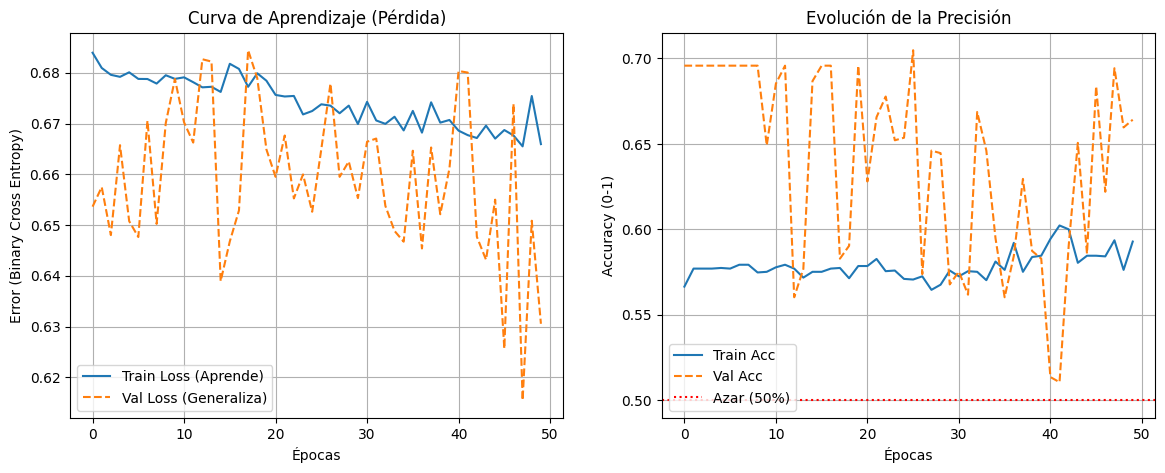

Precisión Final en Test: 66.42%


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Gráfica de PÉRDIDA (Loss)
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss (Aprende)')
plt.plot(val_losses, label='Val Loss (Generaliza)', linestyle='--')
plt.title('Curva de Aprendizaje (Pérdida)')
plt.xlabel('Épocas')
plt.ylabel('Error (Binary Cross Entropy)')
plt.legend()
plt.grid(True)

# Gráfica de PRECISIÓN (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc', linestyle='--')
plt.title('Evolución de la Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (0-1)')
plt.axhline(0.5, color='r', linestyle=':', label='Azar (50%)') # Línea base
plt.legend()
plt.grid(True)

plt.show()

print(f"Precisión Final en Test: {val_accs[-1]:.2%}")

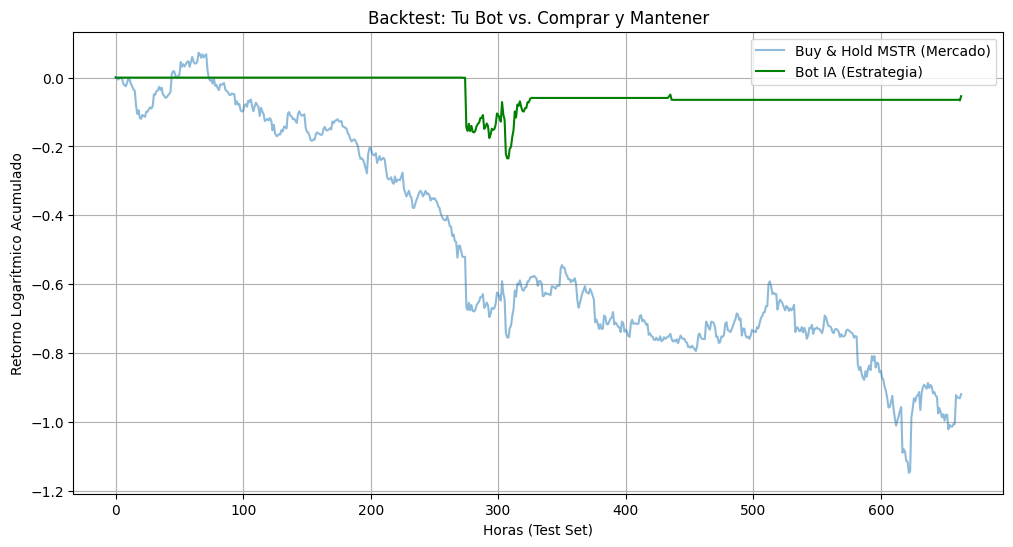

Retorno Total del Bot en el periodo: -0.0539 (aprox -5.39%)
Retorno del Mercado (MSTR) en el periodo: -0.9197


In [11]:
#TEST 1: solo longs con prob > 0.5

import matplotlib.pyplot as plt
import numpy as np

# 1. OBTENER PREDICCIONES DEL MODELO
model.eval()
predictions = []
actuals = []

# Pasamos los datos de test por el modelo
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        predictions.extend(y_pred.squeeze().tolist())
        actuals.extend(y_batch.tolist())

# Convertimos a arrays
predictions = np.array(predictions)
actuals = np.array(actuals)

# 2. SIMULACIÓN DE TRADING (BACKTEST SIMPLE)
# Señal: Si prob > 0.5 Compramos (1), si no Vendemos/Esperamos (0)
# Para hacerlo más agresivo: Si prob > 0.6 Compramos, si prob < 0.4 Vendemos
signals = (predictions > 0.5).astype(int)

# Recuperamos los retornos reales del mercado (necesitamos volver al DataFrame original)
# Truco: Usamos los últimos datos del dataframe original que corresponden al test
# El test son los últimos len(predictions) datos
market_returns = df['lret_mstr'].iloc[-len(predictions):].values
market_returns_btc = df['lret_btc'].iloc[-len(predictions):].values

# 3. CÁLCULO DE BENEFICIOS
# Estrategia: Si Señal es 1, ganamos el retorno de MSTR. Si es 0, nos quedamos en cash (retorno 0).
# (Asumimos que entramos Long. Para Short habría que multiplicar por -1)
strategy_returns = signals * market_returns

# Calculamos la curva de capital acumulada (Cumulative Returns)
cumulative_market = np.cumsum(market_returns)
cumulative_strategy = np.cumsum(strategy_returns)

# 4. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
plt.plot(cumulative_market, label='Buy & Hold MSTR (Mercado)', alpha=0.5)
plt.plot(cumulative_strategy, label='Bot IA (Estrategia)', color='green')
plt.title('Backtest: Tu Bot vs. Comprar y Mantener')
plt.xlabel('Horas (Test Set)')
plt.ylabel('Retorno Logarítmico Acumulado')
plt.legend()
plt.grid(True)
plt.show()

# Métricas finales
total_return = cumulative_strategy[-1]
print(f"Retorno Total del Bot en el periodo: {total_return:.4f} (aprox {total_return*100:.2f}%)")
print(f"Retorno del Mercado (MSTR) en el periodo: {cumulative_market[-1]:.4f}")

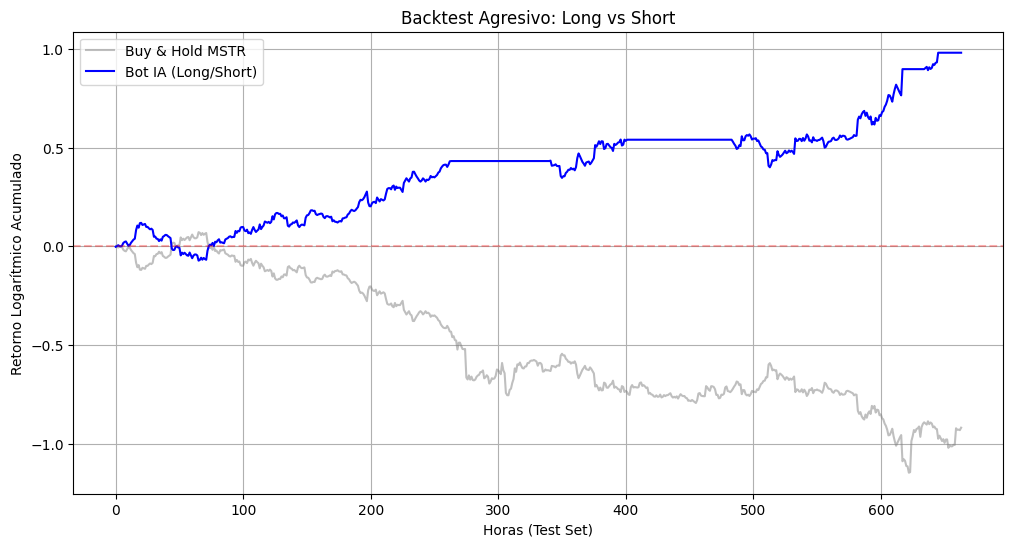

--- RESULTADOS FINALES ---
Retorno Mercado (MSTR): -0.9197
Retorno Bot (L/S):      0.9824

¡ÉXITO! El bot ha batido al mercado.
¡INCREÍBLE! Has ganado dinero en un mercado bajista.


In [12]:
#TEST 2: longs y shorts

import matplotlib.pyplot as plt
import numpy as np

# 1. OBTENER PREDICCIONES (Igual que antes)
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        predictions.extend(y_pred.squeeze().tolist())
        actuals.extend(y_batch.tolist())

predictions = np.array(predictions)

# 2. ESTRATEGIA LONG / SHORT
# Definimos umbrales de confianza
UPPER_THRESHOLD = 0.60 # Para entrar Long
LOWER_THRESHOLD = 0.40 # Para entrar Short

signals = []
for p in predictions:
    if p > UPPER_THRESHOLD:
        signals.append(1)  # Long
    elif p < LOWER_THRESHOLD:
        signals.append(-1) # Short (Ganamos si baja)
    else:
        signals.append(0)  # Neutral (Cash)

signals = np.array(signals)

# 3. CÁLCULO DE RETORNOS
# Recuperamos los retornos del mercado (MSTR)
market_returns = df['lret_mstr'].iloc[-len(predictions):].values

# La magia del Short:
# Si Signal es -1 y el mercado cae (-2%), el retorno es (-1 * -0.02) = +0.02 (+2%)
strategy_returns = signals * market_returns

# 4. CÁLCULO DE CURVAS DE CAPITAL
cumulative_market = np.cumsum(market_returns)
cumulative_strategy = np.cumsum(strategy_returns)

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 6))

# Mercado (MSTR Buy & Hold)
plt.plot(cumulative_market, label='Buy & Hold MSTR', color='gray', alpha=0.5)

# Tu Bot Long/Short
plt.plot(cumulative_strategy, label='Bot IA (Long/Short)', color='blue')

# Dibujamos el "Cero" para ver si ganamos dinero absoluto
plt.axhline(0, color='red', linestyle='--', alpha=0.3)

plt.title('Backtest Agresivo: Long vs Short')
plt.xlabel('Horas (Test Set)')
plt.ylabel('Retorno Logarítmico Acumulado')
plt.legend()
plt.grid(True)
plt.show()

# Métricas
total_return = cumulative_strategy[-1]
market_return = cumulative_market[-1]

print(f"--- RESULTADOS FINALES ---")
print(f"Retorno Mercado (MSTR): {market_return:.4f}")
print(f"Retorno Bot (L/S):      {total_return:.4f}")

if total_return > market_return:
    print("\n¡ÉXITO! El bot ha batido al mercado.")
    if total_return > 0 and market_return < 0:
        print("¡INCREÍBLE! Has ganado dinero en un mercado bajista.")

Simulando operaciones con costes...


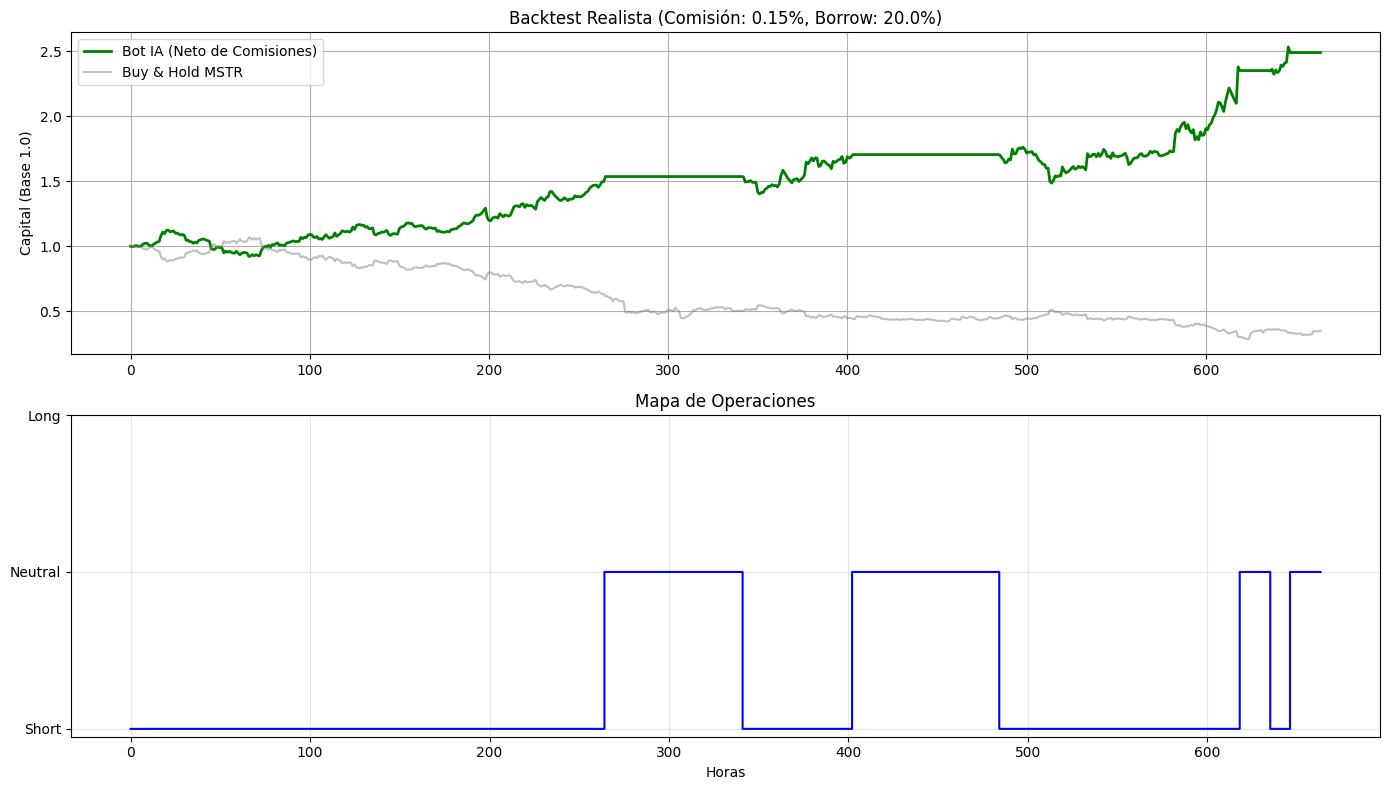

--- RESULTADOS REALISTAS ---
Capital Final: 2.4885 (Retorno: 148.85%)
Total Operaciones (Cambios de estado): 7
Coste estimado en comisiones: 1.05% del volumen rotado


In [13]:
#Test 3: Test 2 pero con comisiones y slippage

import matplotlib.pyplot as plt
import numpy as np

# 1. PARÁMETROS DE COSTES (El "Freno de Mano")
COMMISSION = 0.0015      # 0.15% por operación (incluye spread/slippage)
BORROW_RATE_ANNUAL = 0.20 # 20% anual por mantener shorts
HOURLY_BORROW_RATE = BORROW_RATE_ANNUAL / 365 / 24

# 2. OBTENER SEÑALES (Igual que antes)
# Reutilizamos las predicciones que ya calculaste en la Tarea 9
# predictions = ... (ya lo tienes en memoria)
# market_returns = ... (ya lo tienes en memoria)

# Umbrales
UPPER = 0.60
LOWER = 0.40

# 3. BUCLE DE SIMULACIÓN "EVENT-DRIVEN"
equity_curve = [1.0] # Empezamos con 100% del capital (normalizado a 1)
current_position = 0 # 0: Neutral, 1: Long, -1: Short
positions_history = [] # Para graficar luego cuándo estamos dentro

print("Simulando operaciones con costes...")

for i in range(len(predictions)):
    prob = predictions[i]
    r_market = market_returns[i]
    
    # A. Decidir la Señal del Modelo
    signal = 0
    if prob > UPPER: signal = 1
    elif prob < LOWER: signal = -1
    else: signal = 0
    
    # B. Calcular Costes de Transacción (Solo si cambiamos de posición)
    cost = 0
    if signal != current_position:
        # Pagamos comisión sobre el total de la posición
        # (Simplificación: asumimos reinversión total)
        cost = COMMISSION 
    
    # C. Calcular Retorno del Mercado según la posición ANTERIOR
    # (Ganamos/Perdemos por la posición que traíamos abierta)
    
    # Retorno base de la estrategia en esta hora
    hourly_return = 0
    
    if current_position == 1: # Estábamos Long
        hourly_return = r_market
    elif current_position == -1: # Estábamos Short
        hourly_return = -1 * r_market # Inverso del mercado
        hourly_return -= HOURLY_BORROW_RATE # Restamos el coste del préstamo
    
    # D. Actualizar Capital
    # Fórmula: Capital * (1 + Retorno - Coste)
    # Usamos aproximación logarítmica para sumar, pero para costes es mejor restar al capital.
    # Aquí haremos simulación de Equity simple multiplicativa.
    
    prev_equity = equity_curve[-1]
    new_equity = prev_equity * (1 + hourly_return - cost)
    equity_curve.append(new_equity)
    
    # Actualizamos el estado para la siguiente hora
    current_position = signal
    positions_history.append(current_position)

# 4. VISUALIZACIÓN
plt.figure(figsize=(14, 8))

# Subplot 1: La Curva de Capital (El Dinero)
plt.subplot(2, 1, 1)
plt.plot(equity_curve, label='Bot IA (Neto de Comisiones)', color='green', linewidth=2)
# Reconstruimos la del mercado para comparar (base 1.0)
market_equity = [1.0]
for r in market_returns: market_equity.append(market_equity[-1] * (1 + r))
plt.plot(market_equity, label='Buy & Hold MSTR', color='gray', alpha=0.5)

plt.title(f'Backtest Realista (Comisión: {COMMISSION*100}%, Borrow: {BORROW_RATE_ANNUAL*100}%)')
plt.ylabel('Capital (Base 1.0)')
plt.grid(True)
plt.legend()

# Subplot 2: Posiciones (¿Qué hizo el bot?)
plt.subplot(2, 1, 2)
plt.plot(positions_history, label='Posición (+1 Long, -1 Short, 0 Cash)', color='blue', drawstyle='steps-post')
plt.title('Mapa de Operaciones')
plt.yticks([-1, 0, 1], ['Short', 'Neutral', 'Long'])
plt.xlabel('Horas')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas Finales
final_equity = equity_curve[-1]
total_trades = np.sum(np.abs(np.diff(positions_history)))
print(f"--- RESULTADOS REALISTAS ---")
print(f"Capital Final: {final_equity:.4f} (Retorno: {(final_equity-1)*100:.2f}%)")
print(f"Total Operaciones (Cambios de estado): {total_trades}")
print(f"Coste estimado en comisiones: {total_trades * COMMISSION * 100:.2f}% del volumen rotado")